# Notebook 04 — Structured Baseline Modelling

## Objective

This notebook develops and evaluates structured credit-risk baseline models using the modelling-ready train, validation, and out-of-time test matrices produced in Notebook 03.

Notebook 04 does not repeat feature engineering or preprocessing. Instead, it consumes the persisted 90-feature structured matrices and their corresponding binary targets.

The main objectives are to:

1. load and validate the modelling-ready structured datasets;
2. establish a naïve reference baseline;
3. train an interpretable logistic-regression baseline;
4. train at least one non-linear tree-based baseline;
5. evaluate discrimination using metrics appropriate for an imbalanced binary classification problem;
6. evaluate probability calibration;
7. compare validation and out-of-time test performance; and
8. export model predictions, metrics, and fitted baseline models for later comparison with text-only and hybrid models.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import sparse

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Credit_Risk_Thesis"
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

NB3_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_03"
NB4_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_04"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

NB4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 03 input:", NB3_OUTPUT_DIR)
print("Notebook 04 output:", NB4_OUTPUT_DIR)

Project root: /content/drive/MyDrive/Credit_Risk_Thesis
Notebook 03 input: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_03
Notebook 04 output: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_04


## 1. Load Model-Ready Structured Data

Notebook 03 persisted the final structured matrices and target arrays after feature engineering, temporal splitting, training-only numerical imputation, missingness-indicator construction, and categorical encoding.

These modelling-ready artefacts are loaded directly here so that Notebook 04 can focus exclusively on baseline model development and evaluation.

In [4]:
X_TRAIN_FILE = NB3_OUTPUT_DIR / "X_train_structured.npz"
X_VAL_FILE = NB3_OUTPUT_DIR / "X_val_structured.npz"
X_TEST_FILE = NB3_OUTPUT_DIR / "X_test_structured.npz"

Y_TRAIN_FILE = NB3_OUTPUT_DIR / "y_train.npy"
Y_VAL_FILE = NB3_OUTPUT_DIR / "y_val.npy"
Y_TEST_FILE = NB3_OUTPUT_DIR / "y_test.npy"

FEATURE_NAMES_FILE = (
    NB3_OUTPUT_DIR / "final_structured_feature_names.csv"
)

required_files = [
    X_TRAIN_FILE,
    X_VAL_FILE,
    X_TEST_FILE,
    Y_TRAIN_FILE,
    Y_VAL_FILE,
    Y_TEST_FILE,
    FEATURE_NAMES_FILE
]

for file_path in required_files:
    print(
        file_path.name,
        "->",
        "FOUND" if file_path.exists() else "MISSING"
    )

X_train_structured.npz -> FOUND
X_val_structured.npz -> FOUND
X_test_structured.npz -> FOUND
y_train.npy -> FOUND
y_val.npy -> FOUND
y_test.npy -> FOUND
final_structured_feature_names.csv -> FOUND


In [5]:
X_train = sparse.load_npz(X_TRAIN_FILE)
X_val = sparse.load_npz(X_VAL_FILE)
X_test = sparse.load_npz(X_TEST_FILE)

y_train = np.load(Y_TRAIN_FILE)
y_val = np.load(Y_VAL_FILE)
y_test = np.load(Y_TEST_FILE)

final_structured_feature_names = (
    pd.read_csv(FEATURE_NAMES_FILE)["feature"]
    .tolist()
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print(
    "Structured feature names:",
    len(final_structured_feature_names)
)

X_train: (1119699, 90)
X_val: (169300, 90)
X_test: (56311, 90)
y_train: (1119699,)
y_val: (169300,)
y_test: (56311,)
Structured feature names: 90


In [6]:
assert X_train.shape == (1_119_699, 90)
assert X_val.shape == (169_300, 90)
assert X_test.shape == (56_311, 90)

assert len(y_train) == X_train.shape[0]
assert len(y_val) == X_val.shape[0]
assert len(y_test) == X_test.shape[0]

assert len(final_structured_feature_names) == 90

assert set(np.unique(y_train)) == {0, 1}
assert set(np.unique(y_val)) == {0, 1}
assert set(np.unique(y_test)) == {0, 1}

print("Notebook 03 modelling handoff validated.")

Notebook 03 modelling handoff validated.


## 2. Naïve Reference Baseline

Before training predictive models, a simple reference baseline is established.

Because the task is binary default prediction with an imbalanced target, a majority-class baseline is used as a minimum performance reference. This baseline predicts the non-default class for every observation.

Its purpose is not to provide a useful credit-risk model, but to demonstrate how misleading accuracy can be in an imbalanced classification problem and to provide a lower benchmark for subsequent models.

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [8]:
majority_val_pred = np.zeros_like(y_val)
majority_test_pred = np.zeros_like(y_test)

In [9]:
majority_results = pd.DataFrame([
    {
        "split": "Validation",
        "accuracy": accuracy_score(
            y_val,
            majority_val_pred
        ),
        "precision": precision_score(
            y_val,
            majority_val_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            majority_val_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            majority_val_pred,
            zero_division=0
        )
    },
    {
        "split": "Test",
        "accuracy": accuracy_score(
            y_test,
            majority_test_pred
        ),
        "precision": precision_score(
            y_test,
            majority_test_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            majority_test_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            majority_test_pred,
            zero_division=0
        )
    }
])

majority_results.round(4)

,split,accuracy,precision,recall,f1
0,Validation,0.7688,0.0,0.0,0.0
1,Test,0.8425,0.0,0.0,0.0


### Naïve Baseline Interpretation

The majority-class baseline achieves apparently high accuracy because most loans are non-default observations. However, it identifies no default cases, resulting in zero recall, precision, and F1 score for the positive class.

This demonstrates that accuracy alone is inappropriate for evaluating the credit-risk models in this study. Subsequent model comparison therefore emphasizes discrimination and minority-class performance metrics, including ROC-AUC, PR-AUC, recall, precision, and F1 score.

## 3. Logistic Regression Baseline

Logistic regression is used as the primary interpretable structured baseline. It provides probabilistic default estimates and establishes a linear benchmark against which more complex models can subsequently be evaluated.

Because the structured predictors have heterogeneous numerical scales, feature standardisation is applied before model fitting. The scaler is fitted exclusively on the training set to prevent information leakage. Mean centering is disabled to preserve the sparse representation of the modelling matrices.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train:", X_train_scaled.shape)
print("Scaled validation:", X_val_scaled.shape)
print("Scaled test:", X_test_scaled.shape)

Scaled train: (1119699, 90)
Scaled validation: (169300, 90)
Scaled test: (56311, 90)


In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic regression training completed.")

Logistic regression training completed.


In [12]:
logistic_val_prob = logistic_model.predict_proba(
    X_val_scaled
)[:, 1]

logistic_test_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_val_pred = (
    logistic_val_prob >= 0.5
).astype(int)

logistic_test_pred = (
    logistic_test_prob >= 0.5
).astype(int)

print(
    "Validation predicted-default rate:",
    round(logistic_val_pred.mean() * 100, 2),
    "%"
)

print(
    "Test predicted-default rate:",
    round(logistic_test_pred.mean() * 100, 2),
    "%"
)

Validation predicted-default rate: 2.64 %
Test predicted-default rate: 2.67 %


### 3.1 Model Evaluation Framework

Model performance is evaluated using both discrimination and probability-based metrics.

ROC-AUC measures the model's ability to rank defaulting borrowers above non-defaulting borrowers across classification thresholds. Because default is the minority class, average precision (PR-AUC) is also reported to provide a more informative assessment of positive-class retrieval.

Brier score is included because this study is concerned not only with classification performance but also with the quality of predicted default probabilities. Threshold-dependent precision, recall, F1-score and accuracy are additionally reported at the conventional 0.50 threshold for descriptive comparison.

Model selection will therefore not be based on accuracy alone.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def evaluate_model(
    model_name,
    y_true,
    y_prob,
    threshold=0.5
):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob),
        "predicted_default_pct": y_pred.mean() * 100
    }

In [14]:
logistic_results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression - Validation",
        y_val,
        logistic_val_prob
    ),
    evaluate_model(
        "Logistic Regression - Test",
        y_test,
        logistic_test_prob
    )
])

logistic_results.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,Logistic Regression - Validation,0.7719,0.5599,0.0639,0.1147,0.6924,0.3896,0.1651,2.6397
1,Logistic Regression - Test,0.8358,0.3745,0.0636,0.1087,0.6745,0.2664,0.1292,2.6744


### 3.2 Logistic Regression Baseline Interpretation

The unweighted logistic-regression baseline demonstrated moderate discriminatory
ability, achieving ROC-AUC values of 0.6924 on the 2017 validation cohort and
0.6745 on the 2018 out-of-time test cohort. The reduction in out-of-time
performance indicates some temporal degradation in model discrimination.

At the conventional 0.50 classification threshold, however, the model predicted
only approximately 2.6% of observations as defaults and achieved recall of only
about 6.4% on both evaluation cohorts. Thus, although the model contains useful
ranking information, the default 0.50 threshold provides poor sensitivity for
default identification.

Consequently, threshold-dependent metrics at 0.50 are treated as descriptive
baseline results rather than as an optimized operating policy. Threshold
selection and risk-based decision rules are addressed separately in the later
decision-support analysis.


In [15]:
threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25,
                  0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred = (
        logistic_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "predicted_default_pct": y_pred.mean() * 100,
        "precision": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, y_pred, zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,threshold,predicted_default_pct,precision,recall,f1
0,0.10,76.9610,0.2743,0.9131,0.4219
1,0.15,56.4920,0.3152,0.7700,0.4473
2,0.20,38.8057,0.3574,0.5998,0.4479
3,0.25,25.8665,0.3963,0.4433,0.4185
4,0.30,17.1985,0.4278,0.3182,0.3649
5,0.35,11.3361,0.4625,0.2268,0.3043
6,0.40,7.2764,0.4933,0.1552,0.2362
7,0.45,4.5027,0.5275,0.1027,0.1719
8,0.50,2.6397,0.5599,0.0639,0.1147


### 3.3 Threshold Sensitivity

The validation results demonstrate a substantial precision–recall trade-off.
Reducing the classification threshold markedly increases default recall, but
also increases the proportion of borrowers classified as defaults and reduces
precision.

For example, reducing the threshold from 0.50 to 0.20 increases recall from
6.39% to 59.98%, while precision decreases from 55.99% to 35.74%. The highest
F1 score among the examined thresholds occurs around 0.20; however, this is
not treated as the final operating threshold.

Threshold optimisation is intentionally deferred to the risk-based
decision-support stage, where classification decisions can be evaluated in
terms of their operational consequences rather than selected solely by a
single statistical metric.


### 3.4 Class-Weighted Logistic Regression

A second logistic-regression specification is evaluated using inverse-frequency
class weighting. This gives greater influence to observations from the minority
default class during model fitting.

The purpose of this experiment is to determine whether explicit class-imbalance
handling improves default detection relative to the unweighted logistic
baseline.

Class weighting is evaluated as a modelling choice and is not assumed to
improve probability calibration.


In [16]:
logistic_balanced_model = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_balanced_model.fit(
    X_train_scaled,
    y_train
)

print("Class-weighted logistic regression training completed.")

Class-weighted logistic regression training completed.


In [17]:
logistic_balanced_val_prob = (
    logistic_balanced_model.predict_proba(
        X_val_scaled
    )[:, 1]
)

logistic_balanced_test_prob = (
    logistic_balanced_model.predict_proba(
        X_test_scaled
    )[:, 1]
)

In [18]:
logistic_balanced_results = pd.DataFrame([
    evaluate_model(
        "Balanced Logistic Regression - Validation",
        y_val,
        logistic_balanced_val_prob
    ),
    evaluate_model(
        "Balanced Logistic Regression - Test",
        y_test,
        logistic_balanced_test_prob
    )
])

logistic_balanced_results.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,Balanced Logistic Regression - Validation,0.6529,0.3543,0.6096,0.4482,0.6923,0.3882,0.2172,39.7791
1,Balanced Logistic Regression - Test,0.6623,0.2492,0.5686,0.3466,0.6749,0.2652,0.2146,35.9273


In [19]:
logistic_comparison = pd.concat(
    [
        logistic_results,
        logistic_balanced_results
    ],
    ignore_index=True
)

logistic_comparison.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,Logistic Regression - Validation,0.7719,0.5599,0.0639,0.1147,0.6924,0.3896,0.1651,2.6397
1,Logistic Regression - Test,0.8358,0.3745,0.0636,0.1087,0.6745,0.2664,0.1292,2.6744
2,Balanced Logistic Regression - Validation,0.6529,0.3543,0.6096,0.4482,0.6923,0.3882,0.2172,39.7791
3,Balanced Logistic Regression - Test,0.6623,0.2492,0.5686,0.3466,0.6749,0.2652,0.2146,35.9273


### 3.5 Effect of Class Weighting

Class weighting substantially altered threshold-dependent classification
behaviour but did not materially improve model discrimination.

Validation ROC-AUC remained effectively unchanged (0.6924 versus 0.6923),
while out-of-time test ROC-AUC changed only marginally (0.6745 versus 0.6749).
PR-AUC similarly showed no improvement.

At the conventional 0.50 threshold, class weighting substantially increased
default recall, from 6.39% to 60.96% on validation and from 6.36% to 56.86%
on the out-of-time test cohort. This improvement was accompanied by lower
precision and a much larger proportion of observations being classified as
defaults.

The class-weighted model also produced substantially higher Brier scores,
indicating poorer raw probability accuracy. Therefore, the unweighted
logistic-regression specification is retained as the primary probabilistic
linear baseline, while the class-weighted specification is retained as a
sensitivity analysis for class-imbalance handling.

Threshold optimisation is treated separately from model fitting in the later
risk-based decision-support analysis.

Now let's check Can a non-linear model extract substantially more predictive signal from these same 90 structured features than Logistic Regression?


In [20]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## 4. Gradient-Boosted Tree Baseline

A gradient-boosted tree model is evaluated as the principal non-linear structured baseline.

Unlike logistic regression, gradient-boosted trees can capture non-linear
relationships and interactions between borrower characteristics without
requiring those relationships to be specified manually.

The initial model uses a controlled baseline configuration rather than an
extensive hyperparameter search. This allows the incremental value of
non-linearity to be assessed before model tuning is introduced.


In [21]:
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [22]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=50
)

[0]	validation_0-auc:0.67672	validation_1-auc:0.64799
[50]	validation_0-auc:0.70734	validation_1-auc:0.68124
[100]	validation_0-auc:0.71776	validation_1-auc:0.69570
[150]	validation_0-auc:0.72299	validation_1-auc:0.70256
[200]	validation_0-auc:0.72614	validation_1-auc:0.70604
[250]	validation_0-auc:0.72848	validation_1-auc:0.70831
[300]	validation_0-auc:0.73051	validation_1-auc:0.70993
[350]	validation_0-auc:0.73216	validation_1-auc:0.71104
[400]	validation_0-auc:0.73367	validation_1-auc:0.71192
[450]	validation_0-auc:0.73504	validation_1-auc:0.71253
[499]	validation_0-auc:0.73633	validation_1-auc:0.71306


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [23]:
xgb_val_prob = xgb_model.predict_proba(
    X_val
)[:, 1]

xgb_test_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

In [24]:
xgb_results = pd.DataFrame([
    evaluate_model(
        "XGBoost - Validation",
        y_val,
        xgb_val_prob
    ),
    evaluate_model(
        "XGBoost - Test",
        y_test,
        xgb_test_prob
    )
])

xgb_results.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,XGBoost - Validation,0.7745,0.5912,0.0802,0.1413,0.7131,0.4194,0.1610,3.1370
1,XGBoost - Test,0.8380,0.4376,0.1005,0.1634,0.7090,0.3104,0.1245,3.6156


In [25]:
structured_model_comparison = pd.concat(
    [
        logistic_results,
        xgb_results
    ],
    ignore_index=True
)

structured_model_comparison.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,Logistic Regression - Validation,0.7719,0.5599,0.0639,0.1147,0.6924,0.3896,0.1651,2.6397
1,Logistic Regression - Test,0.8358,0.3745,0.0636,0.1087,0.6745,0.2664,0.1292,2.6744
2,XGBoost - Validation,0.7745,0.5912,0.0802,0.1413,0.7131,0.4194,0.1610,3.1370
3,XGBoost - Test,0.8380,0.4376,0.1005,0.1634,0.7090,0.3104,0.1245,3.6156


### 4.1 Structured Baseline Comparison

The gradient-boosted tree model consistently outperformed the unweighted
logistic-regression baseline across both validation and out-of-time test
cohorts.

On the validation cohort, ROC-AUC increased from 0.6924 to 0.7131 and PR-AUC
from 0.3896 to 0.4194. More importantly, the improvement persisted on the
2018 out-of-time test cohort, where ROC-AUC increased from 0.6745 to 0.7090
and PR-AUC from 0.2664 to 0.3104.

XGBoost also achieved lower Brier scores on both evaluation cohorts, indicating
improved probability accuracy relative to the logistic baseline.

The out-of-time reduction in ROC-AUC was smaller for XGBoost than for logistic
regression, suggesting greater temporal stability in discrimination for the
non-linear model. This finding should nevertheless be interpreted within the
single temporal holdout design used in this study.

At the conventional 0.50 threshold, default recall remained relatively low
for both models. Consequently, these threshold-dependent results are not
treated as final decision policies; operating thresholds are evaluated
separately in the later risk-based decision-support analysis.

Overall, the results indicate that non-linear relationships and interactions
within the structured credit variables provide predictive information beyond
that captured by the linear logistic-regression baseline.


In [26]:
xgb_evals = xgb_model.evals_result()

train_auc_history = xgb_evals["validation_0"]["auc"]
val_auc_history = xgb_evals["validation_1"]["auc"]

best_iteration = int(
    np.argmax(val_auc_history)
)

print("Best validation iteration:", best_iteration + 1)

print(
    "Best validation AUC:",
    round(val_auc_history[best_iteration], 4)
)

print(
    "Training AUC at best iteration:",
    round(train_auc_history[best_iteration], 4)
)

print(
    "Final training AUC:",
    round(train_auc_history[-1], 4)
)

print(
    "Final validation AUC:",
    round(val_auc_history[-1], 4)
)

Best validation iteration: 500
Best validation AUC: 0.7131
Training AUC at best iteration: 0.7363
Final training AUC: 0.7363
Final validation AUC: 0.7131


### 4.2 Boosting Behaviour

Validation ROC-AUC increased through the evaluated 500 boosting rounds and
reached its highest observed value of 0.7131 at the final iteration. Training
ROC-AUC at this point was 0.7363, corresponding to a train-validation gap of
approximately 0.023.

No decline in validation discrimination was observed within the evaluated
boosting horizon, providing no evidence of late-stage overfitting within the
500-round baseline configuration.

Because the best observed iteration occurred at the predefined upper limit,
500 rounds should not be interpreted as a globally optimal number of boosting
iterations. Rather than extending the boosting horizon solely to maximize
validation performance, the current configuration is retained as the
controlled non-linear structured baseline.


In [27]:
xgb_feature_importance = pd.DataFrame({
    "feature": final_structured_feature_names,
    "importance": xgb_model.feature_importances_
})

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

xgb_feature_importance.head(20)

,feature,importance
0,term_ 60 months,0.277359
1,term_ 36 months,0.198915
2,fico_score,0.053950
3,verification_status_Not Verified,0.039735
4,acc_open_past_24mths,0.026104
5,mort_acc,0.018803
6,home_ownership_MORTGAGE,0.018578
7,purpose_credit_card,0.018290
8,dti,0.017033
9,tot_hi_cred_lim,0.016730


### 4.3 Preliminary Structured Feature Importance

The built-in XGBoost importance measure identifies loan term as the dominant
structured predictor, with the one-hot encoded 36-month and 60-month categories
occupying the two highest-ranked positions. Because these dummy variables
represent complementary categories of the same underlying predictor, they
should be interpreted collectively as the contribution of loan term rather
than as two independent risk factors.

Other prominent predictors include FICO score, verification status, recent
credit-account openings, mortgage-account count, home ownership, loan purpose,
debt-to-income ratio, credit limits, and annual income.

These importance values describe predictive contribution within the fitted
tree model and should not be interpreted causally. In addition, built-in tree
importance does not directly indicate whether larger feature values increase
or decrease predicted default risk. More detailed directional and local
interpretation is therefore deferred to the explainability analysis.


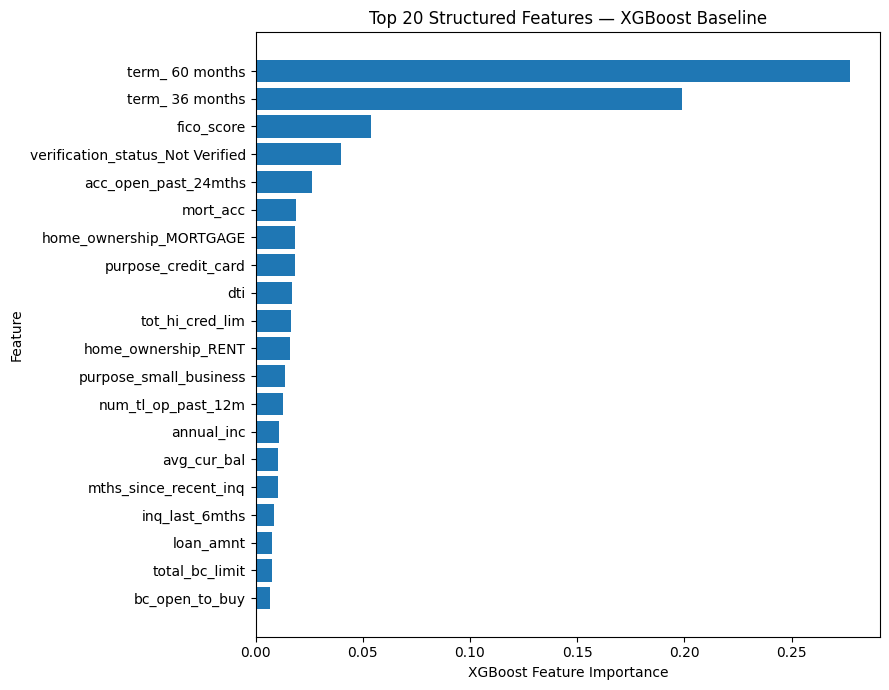

Saved: /content/drive/MyDrive/Credit_Risk_Thesis/outputs/figures/nb04_xgboost_top20_feature_importance.png


In [28]:
import matplotlib.pyplot as plt

top_n = 20

top_features = (
    xgb_feature_importance
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 20 Structured Features — XGBoost Baseline"
)

plt.tight_layout()

feature_importance_plot = (
    FIGURE_DIR /
    "nb04_xgboost_top20_feature_importance.png"
)

plt.savefig(
    feature_importance_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", feature_importance_plot)

In [29]:
xgb_feature_importance.to_csv(
    TABLE_DIR /
    "nb04_xgboost_feature_importance.csv",
    index=False
)

print("Feature-importance table saved.")

Feature-importance table saved.


## 5. Discrimination Curves

ROC and precision-recall curves are used to compare the ranking performance
of the structured baseline models across classification thresholds.

ROC curves summarize the trade-off between true-positive and false-positive
rates, while precision-recall curves provide additional insight into default
detection under class imbalance.


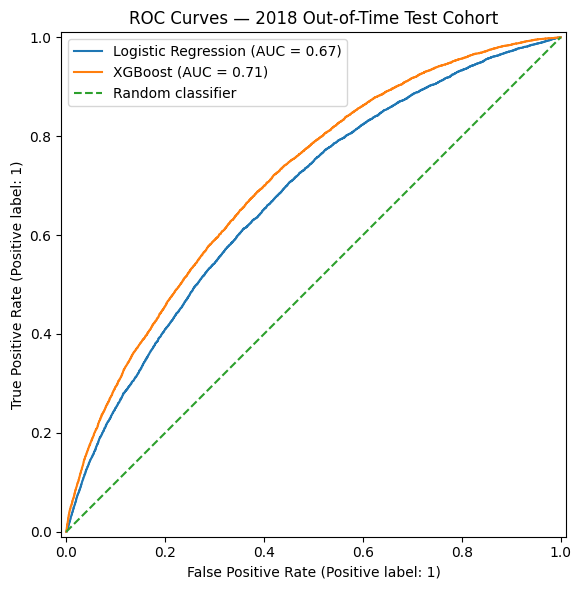

In [30]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_test_prob,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    name="XGBoost",
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

ax.set_title("ROC Curves — 2018 Out-of-Time Test Cohort")
ax.legend()

plt.tight_layout()

roc_plot = FIGURE_DIR / "nb04_structured_roc_test.png"

plt.savefig(
    roc_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

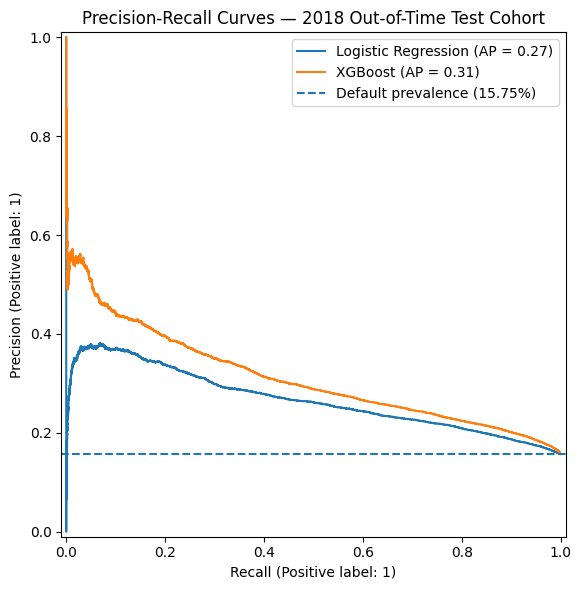

In [31]:
# Precision-recall curve
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    logistic_test_prob,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    name="XGBoost",
    ax=ax
)

baseline_precision = y_test.mean()

ax.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Default prevalence ({baseline_precision:.2%})"
)

ax.set_title(
    "Precision-Recall Curves — 2018 Out-of-Time Test Cohort"
)

ax.legend()

plt.tight_layout()

pr_plot = FIGURE_DIR / "nb04_structured_pr_test.png"

plt.savefig(
    pr_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Probability Calibration Analysis

Credit-risk decision support requires not only discrimination between lower-
and higher-risk borrowers but also reliable probability estimates. Calibration
therefore evaluates whether predicted default probabilities correspond to
observed default frequencies.

Calibration is assessed on the out-of-time test cohort using reliability
curves and the Brier score. This complements ROC-AUC and PR-AUC, which measure
ranking performance but do not establish whether predicted probabilities are
well calibrated.


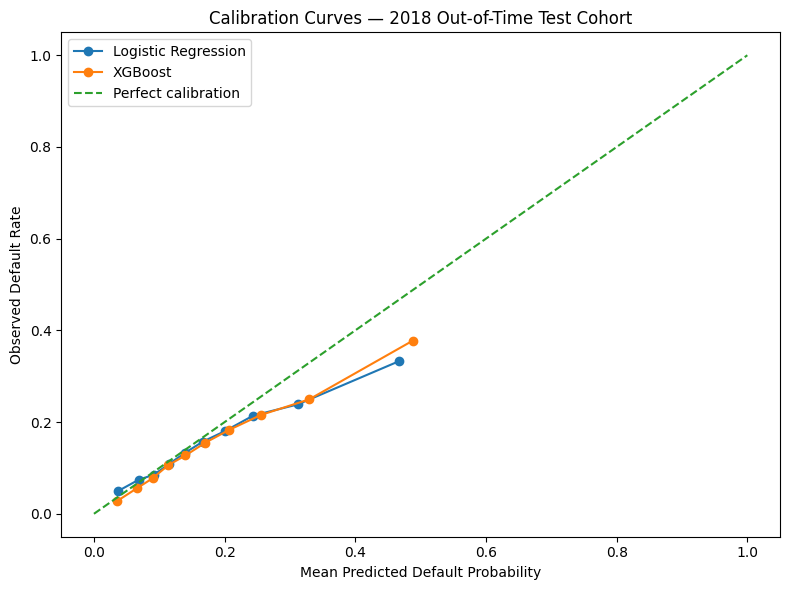

In [32]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for name, probabilities in [
    ("Logistic Regression", logistic_test_prob),
    ("XGBoost", xgb_test_prob)
]:
    observed, predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="quantile"
    )

    ax.plot(
        predicted,
        observed,
        marker="o",
        label=name
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean Predicted Default Probability")
ax.set_ylabel("Observed Default Rate")
ax.set_title(
    "Calibration Curves — 2018 Out-of-Time Test Cohort"
)

ax.legend()

plt.tight_layout()

calibration_plot = (
    FIGURE_DIR /
    "nb04_structured_calibration_test.png"
)

plt.savefig(
    calibration_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import numpy as np
import pandas as pd


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculate Expected Calibration Error (ECE) using
    equal-frequency (quantile) probability bins.
    """
    df = pd.DataFrame({
        "y": np.asarray(y_true),
        "prob": np.asarray(y_prob)
    })

    # qcut produces approximately equally populated bins.
    df["bin"] = pd.qcut(
        df["prob"],
        q=n_bins,
        duplicates="drop"
    )

    grouped = df.groupby(
        "bin",
        observed=True
    ).agg(
        count=("y", "size"),
        observed_rate=("y", "mean"),
        predicted_rate=("prob", "mean")
    )

    grouped["weight"] = grouped["count"] / len(df)

    ece = (
        grouped["weight"]
        * abs(
            grouped["observed_rate"]
            - grouped["predicted_rate"]
        )
    ).sum()

    return ece


calibration_metrics = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "brier_score": brier_score_loss(
            y_test,
            logistic_test_prob
        ),
        "ece_10_bins": expected_calibration_error(
            y_test,
            logistic_test_prob
        )
    },
    {
        "model": "XGBoost",
        "brier_score": brier_score_loss(
            y_test,
            xgb_test_prob
        ),
        "ece_10_bins": expected_calibration_error(
            y_test,
            xgb_test_prob
        )
    }
])

calibration_metrics.round(4)

,model,brier_score,ece_10_bins
0,Logistic Regression,0.1292,0.0304
1,XGBoost,0.1245,0.0320


### 6.1 Post-hoc Calibration of the Structured XGBoost Model

Although XGBoost achieved the strongest structured-model discrimination, its
out-of-time reliability curve showed modest probability miscalibration,
particularly in the higher-risk region. Post-hoc calibration was therefore
evaluated using the 2017 validation cohort.

Two calibration approaches were considered: sigmoid (Platt-style) calibration
and isotonic regression. The underlying XGBoost model was not refitted.
Instead, mappings from its validation-set predicted probabilities to observed
outcomes were learned using validation data only and subsequently applied to
the untouched 2018 test probabilities. This preserves the independence of the
out-of-time test cohort.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# ---------------------------------------------------------
# Sigmoid / Platt-style calibration
# ---------------------------------------------------------

sigmoid_calibrator = LogisticRegression()

sigmoid_calibrator.fit(
    xgb_val_prob.reshape(-1, 1),
    y_val
)

xgb_test_prob_sigmoid = sigmoid_calibrator.predict_proba(
    xgb_test_prob.reshape(-1, 1)
)[:, 1]


# ---------------------------------------------------------
# Isotonic calibration
# ---------------------------------------------------------

isotonic_calibrator = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_calibrator.fit(
    xgb_val_prob,
    y_val
)

xgb_test_prob_isotonic = isotonic_calibrator.predict(
    xgb_test_prob
)

print("Calibration mappings fitted using validation data only.")

Calibration mappings fitted using validation data only.


In [35]:
calibrated_results = []

for name, probabilities in [
    ("Raw XGBoost", xgb_test_prob),
    ("Sigmoid-calibrated XGBoost", xgb_test_prob_sigmoid),
    ("Isotonic-calibrated XGBoost", xgb_test_prob_isotonic)
]:
    calibrated_results.append({
        "model": name,

        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        ),

        "pr_auc": average_precision_score(
            y_test,
            probabilities
        ),

        "brier_score": brier_score_loss(
            y_test,
            probabilities
        ),

        "ece_10_bins": expected_calibration_error(
            y_test,
            probabilities
        )
    })


calibrated_results = pd.DataFrame(calibrated_results)

calibrated_results.round(4)

,model,roc_auc,pr_auc,brier_score,ece_10_bins
0,Raw XGBoost,0.7090,0.3104,0.1245,0.0320
1,Sigmoid-calibrated XGBoost,0.7090,0.3104,0.1296,0.0702
2,Isotonic-calibrated XGBoost,0.7089,0.3061,0.1285,0.0661


### 6.2 Calibration Result

Post-hoc calibration did not improve out-of-time probability reliability.
The raw XGBoost model achieved a Brier score of **0.1245** and an ECE of
**0.0320** on the 2018 test cohort. Sigmoid calibration increased these to
**0.1296** and **0.0702**, respectively, while isotonic calibration produced
a Brier score of **0.1285** and ECE of **0.0661**.

The deterioration is consistent with temporal distribution shift between the
2017 calibration cohort and the 2018 test cohort. In particular, the observed
default rate declined from **23.12% in 2017** to **15.75% in 2018**, limiting
the transferability of a calibration mapping estimated on the preceding
vintage.

Neither pre-specified post-hoc calibration approach demonstrated improved
out-of-time probability reliability relative to the raw XGBoost probabilities.
The raw probability estimates are therefore carried forward as the structured-
baseline output, while the calibration comparison is reported as an out-of-time
sensitivity analysis. This result also demonstrates that improved calibration cannot be
assumed under temporal distribution shift and should be evaluated explicitly
on out-of-time data.


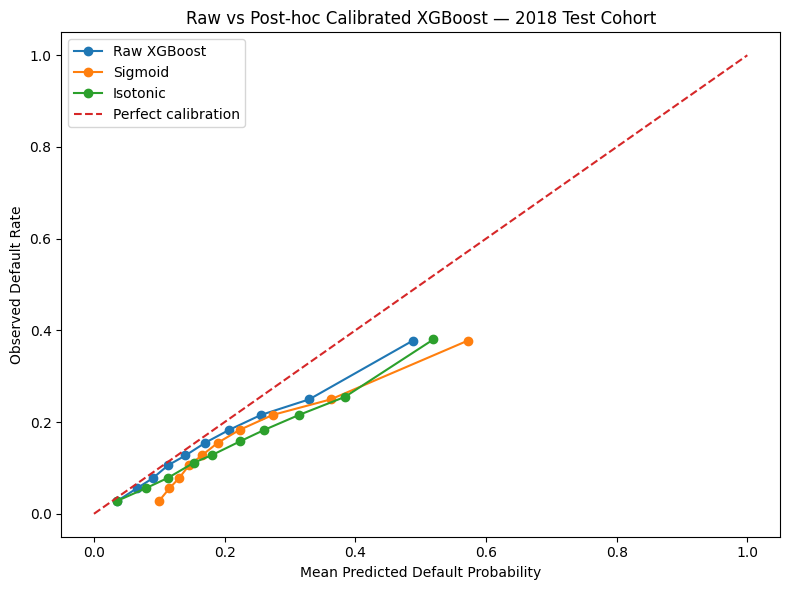

In [36]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

calibration_variants = [
    ("Raw XGBoost", xgb_test_prob),
    ("Sigmoid", xgb_test_prob_sigmoid),
    ("Isotonic", xgb_test_prob_isotonic)
]

for name, probabilities in calibration_variants:

    observed, predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="quantile"
    )

    ax.plot(
        predicted,
        observed,
        marker="o",
        label=name
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean Predicted Default Probability")
ax.set_ylabel("Observed Default Rate")

ax.set_title(
    "Raw vs Post-hoc Calibrated XGBoost — 2018 Test Cohort"
)

ax.legend()

plt.tight_layout()

calibration_comparison_plot = (
    FIGURE_DIR /
    "nb04_xgb_calibration_comparison_test.png"
)

plt.savefig(
    calibration_comparison_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Final Structured Model Comparison

The final comparison evaluates the candidate structured models on the held-out
2018 out-of-time test cohort. Model selection considers discrimination,
class-imbalance-sensitive performance, and probability calibration rather than
classification accuracy alone.


In [37]:
final_structured_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(
            y_test,
            logistic_test_prob
        ),
        "pr_auc": average_precision_score(
            y_test,
            logistic_test_prob
        ),
        "brier_score": brier_score_loss(
            y_test,
            logistic_test_prob
        ),
        "ece_10_bins": expected_calibration_error(
            y_test,
            logistic_test_prob,
            n_bins=10
        )
    },
    {
        "model": "XGBoost",
        "roc_auc": roc_auc_score(
            y_test,
            xgb_test_prob
        ),
        "pr_auc": average_precision_score(
            y_test,
            xgb_test_prob
        ),
        "brier_score": brier_score_loss(
            y_test,
            xgb_test_prob
        ),
        "ece_10_bins": expected_calibration_error(
            y_test,
            xgb_test_prob,
            n_bins=10
        )
    }
])

final_structured_comparison = (
    final_structured_comparison
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

final_structured_comparison.round(4)

,model,roc_auc,pr_auc,brier_score,ece_10_bins
0,XGBoost,0.7090,0.3104,0.1245,0.0320
1,Logistic Regression,0.6745,0.2664,0.1292,0.0304


### Structured Baseline Selection

The final structured-model comparison shows that the raw XGBoost model provides
the strongest overall performance on the 2018 out-of-time test cohort.

Compared with logistic regression, XGBoost achieved higher ROC-AUC (0.7090
versus 0.6745), higher PR-AUC (0.3104 versus 0.2664), and a lower Brier score
(0.1245 versus 0.1292). Logistic regression achieved a marginally lower ECE
(0.0304 versus 0.0320), although the difference was small.

Considering discrimination, minority-class performance, and overall
probability accuracy together, the raw XGBoost model is therefore retained as
the principal structured baseline for subsequent comparison with text-only and
hybrid models.

Post-hoc sigmoid and isotonic calibration were evaluated but did not improve
out-of-time probability reliability. Consequently, the raw XGBoost probability
outputs are retained for downstream analysis.

## 8. Export Structured Baseline Artifacts

The selected structured baseline model, its probability predictions, evaluation
tables, and feature-importance results are persisted for use by subsequent
notebooks. This provides a reproducible handoff to the text, hybrid,
explainability, and decision-support experiments.


In [38]:
import joblib

# ---------------------------------------------------------
# Save fitted models and preprocessing required for reuse
# ---------------------------------------------------------

joblib.dump(
    scaler,
    MODEL_DIR / "nb04_logistic_scaler.joblib"
)

joblib.dump(
    logistic_model,
    MODEL_DIR / "nb04_logistic_regression.joblib"
)

joblib.dump(
    xgb_model,
    MODEL_DIR / "nb04_xgboost_structured.joblib"
)

# ---------------------------------------------------------
# Save evaluation tables
# ---------------------------------------------------------

final_structured_comparison.to_csv(
    TABLE_DIR / "nb04_final_structured_comparison.csv",
    index=False
)

logistic_comparison.to_csv(
    TABLE_DIR / "nb04_logistic_class_weight_comparison.csv",
    index=False
)

threshold_results.to_csv(
    TABLE_DIR / "nb04_logistic_threshold_sensitivity.csv",
    index=False
)

xgb_feature_importance.to_csv(
    TABLE_DIR / "nb04_xgboost_feature_importance.csv",
    index=False
)

calibration_metrics.to_csv(
    TABLE_DIR / "nb04_initial_calibration_metrics.csv",
    index=False
)

calibrated_results.to_csv(
    TABLE_DIR / "nb04_posthoc_calibration_results.csv",
    index=False
)

# ---------------------------------------------------------
# Save validation/test probability outputs
# ---------------------------------------------------------

np.save(
    NB4_OUTPUT_DIR / "logistic_val_prob.npy",
    logistic_val_prob
)

np.save(
    NB4_OUTPUT_DIR / "logistic_test_prob.npy",
    logistic_test_prob
)

np.save(
    NB4_OUTPUT_DIR / "xgb_val_prob.npy",
    xgb_val_prob
)

np.save(
    NB4_OUTPUT_DIR / "xgb_test_prob.npy",
    xgb_test_prob
)

# ---------------------------------------------------------
# Save targets for downstream comparisons
# ---------------------------------------------------------

np.save(
    NB4_OUTPUT_DIR / "y_val.npy",
    y_val
)

np.save(
    NB4_OUTPUT_DIR / "y_test.npy",
    y_test
)

print("Notebook 04 artifacts saved successfully.")


Notebook 04 artifacts saved successfully.


## 9. Notebook 04 Summary and Handoff

### Structured Baseline Modelling

This notebook established the structured credit-risk modelling baselines using
the leakage-controlled and temporally partitioned 90-feature matrices produced
in Notebook 03.

The principal findings were:

1. **Naïve baseline:** Predicting every observation as non-default produced
   apparently high accuracy but zero default recall, demonstrating why accuracy
   alone is inappropriate for this imbalanced credit-risk problem.

2. **Logistic regression:** The unweighted logistic-regression baseline achieved
   moderate discrimination, with ROC-AUC of 0.6924 on the 2017 validation cohort
   and 0.6745 on the 2018 out-of-time test cohort. Its performance at the
   conventional 0.50 threshold showed low default recall, illustrating the
   importance of separating probability modelling from threshold selection.

3. **Class weighting:** Balanced logistic regression substantially increased
   recall at the 0.50 threshold but did not materially improve ROC-AUC or PR-AUC
   and produced poorer Brier scores. The unweighted model was therefore retained
   as the principal linear probabilistic baseline.

4. **Non-linear modelling:** XGBoost improved structured-data discrimination,
   achieving test ROC-AUC of 0.7090 and PR-AUC of 0.3104 compared with 0.6745
   and 0.2664 for logistic regression. XGBoost also achieved the lower test
   Brier score of 0.1245.

5. **Temporal generalisation:** XGBoost exhibited a smaller reduction in
   ROC-AUC between the 2017 validation and 2018 test cohorts than logistic
   regression, providing evidence of stronger discrimination under the
   evaluated temporal holdout design.

6. **Feature importance:** Preliminary XGBoost importance analysis identified
   loan term, FICO score, verification status, recent credit-account activity,
   mortgage-account information, home ownership, loan purpose, debt-to-income
   ratio, credit limits, and income among the prominent structured predictors.
   These results represent predictive associations rather than causal effects.

7. **Probability calibration:** The raw XGBoost model showed modest
   out-of-time calibration error. Post-hoc sigmoid and isotonic calibration,
   fitted using the 2017 validation cohort, did not demonstrate improved
   probability reliability on the 2018 test cohort. The raw XGBoost probability
   stream is therefore carried forward, with the calibration comparison treated
   as an out-of-time sensitivity analysis.

### Selected Structured Baseline

The **raw XGBoost model** is retained as the principal structured baseline for
subsequent experiments because it provides the strongest overall combination
of out-of-time discrimination, minority-class ranking performance, and
probability accuracy.

The 0.50 classification threshold is not treated as the final operational
decision threshold. Threshold and risk-band selection are deferred to the
risk-based decision-support analysis.

### Handoff to Subsequent Notebooks

The fitted structured models, XGBoost validation and test probabilities,
evaluation tables, feature-importance results, and calibration results have
been persisted as reusable artefacts.

Subsequent experiments will evaluate text-only and hybrid structured-text
models on the matched text-eligible temporal cohort established in Notebook 03.
The structured baseline results produced here provide the reference point for
assessing whether borrower-written text contributes incremental predictive
value.
